![](policy_episode_2000.gif)

# Reinforcement Learning Demonstrations: Q-Learning and Monte Carlo

This notebook serves as an interactive demonstration for understanding and comparing two fundamental reinforcement learning algorithms: **Q-Learning** and **Monte Carlo Control**. Using the classic **FrozenLake-v1** environment from Gymnasium, we aim to illustrate how these agents learn to navigate a stochastic environment to achieve a goal.

### What this Notebook Teaches:
*   **Reinforcement Learning Fundamentals:** Concepts such as states, actions, rewards, policies, value functions, and the exploration-exploitation trade-off.
*   **Q-Learning:** How this Temporal Difference (TD) learning algorithm uses Bellman equations to iteratively update Q-values and converge to an optimal policy.
*   **Monte Carlo Control:** How this episodic learning method estimates state-action values from complete returns and uses them to improve its policy.
*   **Comparison of Algorithms:** Understanding the key differences, strengths, and weaknesses of Q-Learning and Monte Carlo in a challenging, slippery environment.

### Experiments Conducted:
We will train and demonstrate both a **Q-Learning Agent** and a **Monte Carlo Agent** on the `FrozenLake-v1` environment. Each agent will undergo a specified number of training episodes, during which their learning progress will be recorded and visualized.

### Tools and Demonstrations for Intermediate Steps:
To provide deep insights into the learning process, the notebook utilizes several visualizations and logging mechanisms, demonstrating intermediate steps:
*   **Episode Rewards Over Time:** A learning curve showing cumulative rewards per episode, often including a rolling average to smooth out fluctuations.
*   **Value Function Visualizations (Heatmaps):** Periodic plots illustrating how the agent's estimated value (V-value) for each state evolves as training progresses.
*   **Policy Animations (GIFs):** Dynamic visualizations of the agent executing its current policy at different stages of training, showing its learned behavior.
*   **Bellman Backup Visualizations (for Q-Learning):** Detailed logs of individual Q-value updates, showing the current Q(s,a), target Q, TD error, and updated Q(s,a).
*   **Final Q-Tables and Policies:** The converged Q-value table and the derived optimal policy for each agent.
*   **Comparison of Learned Policies:** Side-by-side analysis of the final policies from both algorithms to highlight their differences and similarities.

## Explanation of analysis tool outputs

### Explanation of the Learning Curve Plot

The learning curve plot, titled 'Episode Rewards Over Time', is a crucial visualization that helps us understand how well our Q-Learning agent performed during training and if it learned successfully. Here's a breakdown:

*   **X-axis (Episode):** This represents the number of training episodes completed. As the agent interacts with the environment over many episodes, it gradually refines its Q-table and policy.
*   **Y-axis (Total Reward):** This shows the cumulative reward the agent received in each individual episode. A higher total reward generally indicates better performance.

**Interpretation:**

Ideally, in a successful reinforcement learning scenario, we would expect the total reward per episode to gradually increase over time and eventually stabilize at a high value. This indicates that the agent is learning to find optimal or near-optimal policies that maximize rewards.

In the case of our 'FrozenLake-v1' environment, you might observe a learning curve that:

1.  **Starts Low:** Early episodes often show low or even zero rewards because the agent is exploring randomly (`initial_epsilon` was 1.0), and hasn't yet learned the optimal path.
2.  **Increases Gradually:** As the agent explores and updates its Q-table, it starts discovering better actions and paths, leading to an increase in total rewards.
3.  **Fluctuates:** Due to the probabilistic nature of the environment (e.g., 'slippery' FrozenLake) and the exploration strategy, there might be fluctuations in rewards between episodes, even after the agent has learned a good policy.
4.  **Plateaus:** Eventually, the curve should plateau, meaning the agent has converged to a stable policy where it consistently achieves a certain level of reward.

Looking at the plot generated, you can trace this progression. While 'FrozenLake-v1' can be challenging due to its slippery nature, a well-tuned Q-learning agent typically shows an upward trend in rewards, demonstrating that it's learning to navigate the ice and reach the goal.

### Explanation of the Bellman Backup Visualizations

The Bellman backup visualizations provide a detailed, step-by-step look into how the Q-Learning agent updates its knowledge (its Q-table) after interacting with the environment. It's the core learning mechanism of Q-learning, derived from the Bellman Equation.

Let's break down an example output from the visualization:

```
--- Bellman Backup Visualization ---
Episode: 100
State: 0, Action: 1, Reward: 0, Next State: 1, Done: False
  Current Q(s,a): 0.0000
  Target Q: 0.0000
  TD Error: 0.0000
  Updated Q(s,a): 0.0000
----------------------------------
```

Here’s what each part means:

*   **`Episode`**: This tells you which training episode the backup occurred in. We configured it to show a backup at the start of every 100th episode in the `train_and_demonstrate` function.
*   **`State`, `Action`, `Reward`, `Next State`, `Done`**: These represent a single transition the agent experienced:
    *   **`State`**: The state the agent was in before taking an action (e.g., `0` for the starting cell in FrozenLake).
    *   **`Action`**: The action the agent chose to take from that state (e.g., `1` could be 'down').
    *   **`Reward`**: The immediate reward the agent received after taking that action (e.g., `0` for moving to an ordinary cell, or `1` for reaching the goal).
    *   **`Next State`**: The state the agent landed in after taking the action.
    *   **`Done`**: A boolean (`True` or `False`) indicating if the episode terminated after this step (e.g., reaching a hole or the goal).
*   **`Current Q(s,a)`**: This is the agent's current estimate of the value of taking `Action` in `State` *before* the update. It's the value stored in the `q_table[state, action]` cell.
*   **`Target Q`**: This is the value that the Q-learning algorithm considers to be the 'true' or 'better' value for `Q(s,a)` based on the Bellman equation. It's calculated as: `Reward + gamma * max(Q(next_state, a'))`. If `Done` is `True`, it's just the `Reward` (as there are no future rewards).
    *   **`gamma` (Discount Factor)**: This parameter determines the importance of future rewards. A higher `gamma` (closer to 1) means the agent considers future rewards more heavily.
*   **`TD Error` (Temporal Difference Error)**: This is the difference between the `Target Q` and the `Current Q(s,a)` (`Target Q - Current Q(s,a)`). A positive TD Error means the agent underestimated the value of `(state, action)`, while a negative error means it overestimated.
*   **`Updated Q(s,a)`**: This is the new Q-value for `(state, action)` *after* the update. It's calculated using the formula: `Current Q(s,a) + alpha * TD Error`.
    *   **`alpha` (Learning Rate)**: This parameter controls how much the agent updates its Q-value based on the new information (the TD Error). A higher `alpha` means the agent gives more weight to recent experiences.

In essence, each Bellman backup visualization shows one instance of the agent learning from experience: it compares what it thought was going to happen (`Current Q`) with what actually happened and what it now believes is the best outcome (`Target Q`), then adjusts its belief (`Updated Q`) based on the difference (`TD Error`) and its learning rate (`alpha`). Over many such updates, the Q-table gradually converges to an optimal set of values.

### Explanation of the Value Function Visualizations

These visualizations, typically presented as heatmaps, show the agent's estimated value (V-value) for each state in the environment. The V-value of a state `s` represents the maximum expected cumulative reward the agent can achieve starting from that state, following its current policy.

**Interpretation:**

*   **Colors and Numerical Values:** On the heatmap, different colors (and the numerical annotations) represent the magnitude of the V-value. Generally, warmer colors (e.g., yellow, orange) or higher numerical values indicate states that the agent considers more desirable or 'valuable' to be in, as they are believed to lead to higher future rewards. Cooler colors (e.g., blue, purple) or lower values indicate less desirable states.
*   **Evolution Over Training:** As the training progresses, you can observe how these V-values change. Initially, the values might be uniform or reflect random exploration. As the agent learns, the values of states closer to the goal (reward) will gradually increase, while the values of states near hazards (e.g., holes in FrozenLake) or states that lead to dead ends will decrease or remain low. This evolution visually demonstrates the agent's growing understanding of the environment's reward structure.
*   **Converged Value Function:** In a well-trained agent, the value function should converge, meaning the V-values for each state become stable. The converged heatmap will clearly show the 'path' of highest value leading from the starting state to the goal state, reflecting the optimal or near-optimal policy learned by the agent. For 'FrozenLake-v1', you should see higher values clustered around the goal (`G`) and lower values around the holes (`H`).

### Explanation of the Policy Animations

The policy animations (GIFs) provide a dynamic and intuitive way to observe the agent's learned behavior in the environment. Each GIF shows the agent executing its current optimal policy (derived from its Q-table) for a specified number of steps or until the episode ends.

**Interpretation:**

*   **Demonstrating Agent Behavior:** The animation visually traces the agent's movement and actions within the environment. You can see the agent's trajectory from the starting state through various intermediate states.
*   **Observing Policy Effectiveness:** By watching the animations at different stages of training, you can assess how 'smart' the agent has become:
    *   **Early Training:** Animations from early episodes will likely show the agent moving randomly, often falling into holes or taking inefficient paths, reflecting its high exploration rate and unrefined Q-table.
    *   **Later Training:** Animations from later episodes, especially after the Q-table has largely converged, should depict the agent taking more direct and successful paths towards the goal, demonstrating a more deliberate and optimal policy. The agent will consistently try to avoid obstacles and reach the reward.
*   **Reinforcing Learning Concepts:** These animations visually connect the abstract Q-values and policies to concrete actions within the environment, making the learning process more tangible. They help confirm that the agent isn't just updating numbers in a table, but genuinely learning how to navigate and succeed in its environment.

### Analysis of Q-values for the Trained Policy (Summary)

The Q-table and the final policy derived from it indicate that the agent has learned a strategy to navigate the FrozenLake environment. Here are the key observations from the displayed Q-table and policy:

*   **Goal-Oriented Values:** States closer to the goal (`G` - state 15, a terminal state) or states that directly lead to it show higher Q-values for actions moving in that direction. For instance, State 14, which is adjacent to the goal, has its highest Q-value for the 'Right' action (0.728304), leading the policy to choose `Right` for this state.
*   **Hole States:** Terminal hole states (states 5, 7, 11, 12) correctly exhibit Q-values of `0.0000` for all actions, as there are no further rewards or future states from a hole.
*   **Discounting Effect:** A general trend shows Q-values decreasing as states are further away from the goal, reflecting the `gamma` (discount factor) which prioritizes immediate rewards over distant future rewards.
*   **Slippery Environment Impact:** Due to the 'slippery' nature of the FrozenLake environment, the Q-values, even for optimal actions, might not be as high as in a deterministic setting. The agent has learned to account for the probabilistic outcomes of its actions.

**Derived Policy:**

The `final_policy` table directly translates the highest Q-value for each state into an optimal action. For example:

*   **State 0 (Start):** The policy dictates moving `Left` (action 0), indicating this was determined as the most advantageous initial move in the learned strategy.
*   **State 14 (Near Goal):** The policy correctly selects `Right` (action 2), which leads to the Goal state.

In essence, the Q-table and the resulting policy demonstrate the agent's learned understanding of the environment's reward structure and its ability to adapt its behavior to the stochastic elements of the FrozenLake problem.

# Environment Description: FrozenLake-v1

This demonstration utilizes the `FrozenLake-v1` environment from the Gymnasium library. FrozenLake is a classic grid-world reinforcement learning problem.

**Environment Overview:**

The agent controls movement on a grid. The goal is to reach the frozen lake's goal (`G`) from the starting point (`S`) without falling into any holes (`H`). The ice is slippery, meaning the agent's actions may not always move it in the intended direction; there's a chance of slipping to an adjacent tile. This stochasticity makes the problem more challenging.

*   **States:** The environment consists of a discrete state space representing each tile on the grid. For the default 4x4 version, there are 16 possible states (0-15).
    *   `S`: Starting point, safe.
    *   `F`: Frozen surface, safe.
    *   `H`: Hole, fall to your doom.
    *   `G`: Goal, where the agent receives a reward.

*   **Actions:** The agent has 4 discrete actions available:
    *   `0`: Move Left
    *   `1`: Move Down
    *   `2`: Move Right
    *   `3`: Move Up

*   **Rewards:**
    *   Reaching the goal (`G`): +1 reward.
    *   Falling into a hole (`H`): 0 reward (and episode terminates).
    *   Moving on frozen surface (`F`): 0 reward.

*   **Slippery Ice:** The environment has a `is_slippery=True` default setting, meaning there's a 1/3 chance of moving in the intended direction, and a 1/3 chance of moving to each of the two perpendicular directions. This adds a probabilistic element, requiring the agent to learn robust policies.

This environment is a good testbed for value-based methods like Q-Learning because of its discrete state and action spaces, and its clear reward structure, while the slipperiness introduces an element of uncertainty that makes learning non-trivial.

# The Q-learning and Monte-Carlo methods


## Q-learning

1.  **Q-Value (Action-Value Function)**:
    *   The "Q" in Q-learning stands for "Quality". A Q-value, denoted as `Q(s, a)`, represents the **expected future reward** of taking action `a` in state `s`, and then following an optimal policy thereafter.
    *   The goal of Q-learning is to learn a Q-table, which stores the `Q(s, a)` for all possible state-action pairs.

2.  **Optimal Policy ($\pi^*$ )**:
    *   The optimal policy dictates the best action to take in each state to maximize the cumulative future reward.
    *   Once the Q-table converges to its optimal values (`Q*`), the optimal policy can be derived by simply choosing the action `a` that has the maximum `Q(s, a)` for each state `s`: $\pi^*(s) = \arg\max_a Q^*(s, a)$.

3.  **Exploration vs. Exploitation**:
    *   **Exploration**: The agent tries new actions to discover potentially more rewarding paths.
    *   **Exploitation**: The agent chooses the action it currently believes will yield the highest reward based on its current Q-table.
    *   Q-learning typically uses an **epsilon-greedy strategy** to balance these: with probability $\epsilon$ (epsilon), it chooses a random action (exploration); with probability $1 - \epsilon$, it chooses the action with the highest Q-value (exploitation). Epsilon usually starts high and decays over time to favor exploitation as the agent learns.

### How Q-Learning Works (The Bellman Equation for Q-Values)

Q-learning iteratively updates its Q-values using the Bellman equation. For each step of interaction with the environment, where the agent transitions from state $s$ to state $s'$ by taking action $a$, receives reward $r$, and the episode may or may not be terminated (`done`):

The update rule is:

$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$

Let's break down each component:

*   **$Q(s, a)$**: The current estimated Q-value for taking action $a$ in state $s$.
*   **$\alpha$ (Learning Rate)**: A value between 0 and 1. It determines how much new information overrides old information. A high $\alpha$ makes the agent learn quickly but might lead to instability; a low $\alpha$ leads to slower but potentially more stable learning.
*   **$r$ (Reward)**: The immediate reward received after taking action $a$ in state $s$ and transitioning to state $s'$.
*   **$\gamma$ (Discount Factor)**: A value between 0 and 1. It determines the importance of future rewards. A $\gamma$ close to 0 makes the agent myopic (only cares about immediate rewards); a $\gamma$ close to 1 makes it consider future rewards heavily.
*   **$\max_{a'} Q(s', a')$**: This is the core of the TD update. It represents the maximum estimated Q-value for the next state $s'$ across all possible actions $a'$ that can be taken from $s'$. If the next state $s'$ is a terminal state (i.e., `done` is `True`), then $\max_{a'} Q(s', a')$ is 0, as there are no future rewards.
*   **$[r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$ (Temporal Difference (TD) Error)**: This is the difference between the "newly estimated value" ($r + \gamma \max_{a'} Q(s', a')$) and the "old estimated value" ($Q(s, a)$). The agent learns by trying to reduce this error.

### Key Characteristics

*   **Model-Free**: Does not require knowledge of the environment's transition probabilities or reward function. It learns directly from interacting with the environment.
*   **Off-Policy**: It learns the value of the optimal policy (the one that maximizes $\max_{a'} Q(s', a')$) while following a different policy (the epsilon-greedy policy for exploration). This allows it to explore widely while still converging to the optimal policy.
*   **Guaranteed Convergence (under certain conditions)**: If the environment is an MDP, all state-action pairs are visited infinitely often, and the learning rate decays appropriately, Q-learning is guaranteed to converge to the optimal Q-values.

In summary, Q-learning is a powerful and widely used algorithm that allows an agent to learn optimal actions in an unknown environment by iteratively refining its estimates of the value of taking specific actions in specific states."""
)

## Monte Carlo Control Explanation

Monte Carlo (MC) control methods are a class of Reinforcement Learning algorithms that learn optimal policies from experience, specifically from complete episodes of interaction with the environment. Unlike Temporal Difference (TD) learning methods (like Q-Learning) that update value estimates incrementally at each step, MC methods only update their value estimates *after* an entire episode has concluded.

**Key Characteristics:**

1.  **Episodic Task Requirement**: MC control is suitable for episodic tasks, meaning tasks that have a clear beginning and end. The agent needs to complete an entire episode to calculate the *return* (the total discounted reward).

2.  **Learning from Complete Returns**: For each state-action pair `(s, a)` visited in an episode, MC calculates the actual return `G` (the sum of discounted rewards from that point forward). This `G` is then used to update the estimated value of `Q(s, a)`.

3.  **First-Visit vs. Every-Visit MC**:
    *   **First-Visit MC**: If a state-action pair `(s, a)` is visited multiple times in an episode, only the first occurrence's return is used for the update. This is what was implemented in the `MonteCarloAgent`.
    *   **Every-Visit MC**: All occurrences of `(s, a)` in an episode contribute to the update.

4.  **Exploration**: To ensure all state-action pairs are sufficiently explored, MC control typically uses an epsilon-greedy policy, similar to Q-Learning. This involves sometimes choosing a random action (exploration) instead of the greedily optimal action (exploitation).

5.  **Policy Improvement**: After updating the Q-values based on the collected returns, the policy is improved by making it greedy with respect to the new Q-values. This means for each state, the agent chooses the action that has the highest estimated Q-value.

**Update Rule (First-Visit MC):**

For each `(state, action)` pair observed in an episode:

`Q(s, a) = Q(s, a) + (1 / N(s, a)) * (G - Q(s, a))`

Where:
*   `Q(s, a)` is the estimated value of taking action `a` in state `s`.
*   `G` is the return (total discounted reward) observed following the first visit to `(s, a)` in the episode.
*   `N(s, a)` is the count of how many times `(s, a)` has been visited (specifically, how many times `G` has been collected for its first visit).

In essence, Monte Carlo methods average the returns observed for each state-action pair to estimate their true values. This averaging process ensures that the estimates converge to the true expected returns over many episodes.

## Comparison of methods

### Analysis of Policy Differences

Observing the two policies side-by-side, we can draw a few conclusions:

*   **Similarities for Key States:** For critical states, especially those directly adjacent to the goal (e.g., State 14 leading `Right`), both algorithms tend to converge to the same optimal action. This indicates a strong signal for these paths.

*   **Differences in Early/Intermediate States:** You might notice variations in actions for states further from the goal or in more ambiguous parts of the grid. These differences can arise due to:
    *   **Learning Approach:** Q-Learning is a Temporal Difference method, updating Q-values based on estimated future rewards from the *next state*, even if it hasn't been fully explored. Monte Carlo, on the other hand, learns from *complete episodes* and actual returns. In a slippery environment, this difference can lead to varying estimates, especially if some paths rarely lead to success during MC's exploration.
    *   **Exploration-Exploitation Trade-off:** The specific exploration paths taken by each agent (even with the same epsilon-greedy strategy) can influence which state-action pairs get updated more frequently and with what experiences.
    *   **Convergence Speed & Stability:** Q-Learning often converges faster in environments with many states because it updates its estimates more frequently. Monte Carlo needs to complete an entire episode, which can be long or unsuccessful in FrozenLake, potentially leading to slower or less stable updates for some state-action pairs.
    *   **Stochasticity Handling:** The 'slippery' nature of FrozenLake means actions don't always yield the intended outcome. Both algorithms try to account for this, but their methods of propagating value (bootstrapping in Q-Learning vs. full returns in MC) can lead to different 'preferred' actions when facing uncertainty.

In summary, while both policies aim for the optimal path, the underlying learning mechanisms (TD vs. Monte Carlo) and the specifics of the training runs (randomness in exploration, episode outcomes) contribute to the observed variations. Understanding these differences helps appreciate the strengths and weaknesses of each algorithm.

# Task: Final version of code
Update the `visualize_bellman_backup` function to save its textual output to a file within the current run's unique output directory, then update the `RLDemonstrator`'s `train` method to pass the output directory to this function, and finally update the `_generate_key_observations_markdown` method to include references to these saved Bellman backup files. After these updates, re-run both the Q-Learning and Monte Carlo demonstration blocks to generate all updated artifacts in their respective unique output directories.

## Update All Function and Class Definitions

### Subtask:
Execute the code block containing the latest definitions for initialize_environment, QLearningAgent, MonteCarloAgent, visualize_bellman_backup, animate_policy, plot_value_function, and the RLDemonstrator class. This ensures all modifications, including rolling average plotting, initial visualizations, and updated markdown generation, are active.


**Reasoning**:
I need to execute the code block containing the latest definitions for all helper functions and classes to ensure they are active and correctly incorporate all updates, including the numpy import, bellman backup logging, and updated markdown generation.



In [ ]:
import matplotlib.pyplot as plt
from IPython.display import Image, display # Import Image and display for Colab rendering
import os
import datetime
import pandas as pd # Import pandas for DataFrame operations
import PIL.Image
import imageio.v2 as imageio
from PIL import ImageDraw, ImageFont # Import ImageDraw and ImageFont
import numpy as np # Explicitly import numpy here

# Helper function definitions (re-included for context and modifications)
def initialize_environment(env_name, render_mode=None):
    import gymnasium as gym
    print(f"Initializing environment: {env_name}")
    env = gym.make(env_name, render_mode=render_mode) # Pass render_mode here
    print("\nObservation Space:")
    print(env.observation_space)
    print("\nAction Space:")
    print(env.action_space)
    return env

# Mock/placeholder for QLearningAgent if not imported from previous step
class QLearningAgent:
    def __init__(self, obs_space_size, action_space_size, alpha=0.1, gamma=0.99, epsilon=1.0):
        self.obs_space_size = obs_space_size
        self.action_space_size = action_space_size
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((obs_space_size, action_space_size))

    def choose_action(self, state):
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.randint(self.action_space_size)
        else:
            q_values = self.q_table[state, :]
            max_q = np.max(q_values)
            best_actions = np.where(q_values == max_q)[0]
            return np.random.choice(best_actions)

    def learn(self, state, action, reward, next_state, done):
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_table[next_state, :])
        self.q_table[state, action] = self.q_table[state, action] + self.alpha * (target_q - self.q_table[state, action])

    def get_policy(self):
        return np.argmax(self.q_table, axis=1)

# Mock/placeholder for MonteCarloAgent if not imported from previous step
class MonteCarloAgent:
    def __init__(self, obs_space_size, action_space_size, gamma=0.99, epsilon=1.0):
        self.obs_space_size = obs_space_size
        self.action_space_size = action_space_size
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((obs_space_size, action_space_size))
        self.sa_counts = np.zeros((obs_space_size, action_space_size))

    def choose_action(self, state):
        if np.random.uniform(0, 1) < self.epsilon:
            return np.random.randint(self.action_space_size) # Explore: choose random action
        else:
            # Exploit: choose action with max Q-value (handle ties randomly)
            q_values = self.q_table[state, :]
            max_q = np.max(q_values)
            best_actions = np.where(q_values == max_q)[0]
            return np.random.choice(best_actions)

    def learn_episode(self, episode_history):
        G = 0 # Initialize return
        visited_sa = set() # To track (state, action) pairs for first-visit MC

        # Iterate through the episode history in reverse order
        for state, action, reward in reversed(episode_history):
            G = reward + self.gamma * G

            # Apply first-visit MC update
            if (state, action) not in visited_sa:
                self.sa_counts[state, action] += 1
                # Running average update
                self.q_table[state, action] = self.q_table[state, action] + \
                                            (G - self.q_table[state, action]) / self.sa_counts[state, action]
                visited_sa.add((state, action))

    def get_policy(self):
        return np.argmax(self.q_table, axis=1)

def visualize_bellman_backup(q_table, state, action, reward, next_state, done, alpha, gamma, current_episode=None, save_dir=None):
    output_str = "\n--- Bellman Backup Visualization ---\n"
    if current_episode is not None:
        output_str += f"Episode: {current_episode}\n"
    output_str += f"State: {state}, Action: {action}, Reward: {reward}, Next State: {next_state}, Done: {done}\n"

    current_q = q_table[state, action]

    if done:
        target_q = reward
    else:
        target_q = reward + gamma * np.max(q_table[next_state, :])

    td_error = target_q - current_q
    new_q = current_q + alpha * td_error

    output_str += f"  Current Q(s,a): {current_q:.4f}\n"
    output_str += f"  Target Q: {target_q:.4f}\n"
    output_str += f"  TD Error: {td_error:.4f}\n"
    output_str += f"  Updated Q(s,a): {new_q:.4f}\n"
    output_str += "----------------------------------\n"

    print(output_str)

    if save_dir:
        filepath = os.path.join(save_dir, 'bellman_backups.txt')
        with open(filepath, 'a') as f:
            f.write(output_str)

def animate_policy(env, policy, output_filename, num_steps=100, save_dir=None):
    frames = []
    observation, info = env.reset()
    done = False
    step_count = 0
    total_reward = 0

    print(f"Generating animation for policy (saving to {output_filename})...\n")

    try:
        font = ImageFont.truetype("arial.ttf", 15)
    except IOError:
        font = ImageFont.load_default()

    while not done and step_count < num_steps:
        frame = env.render()
        if frame is None:
            print("Warning: env.render() returned None. Check rendering setup.")
            break

        pil_img = PIL.Image.fromarray(frame)
        draw = ImageDraw.Draw(pil_img)
        text = f"Reward: {total_reward:.2f}"
        draw.text((10, 10), text, font=font, fill=(255, 255, 255))
        frames.append(pil_img)

        action = policy[observation]
        next_observation, reward, terminated, truncated, info = env.step(action)

        observation = next_observation
        total_reward += reward
        done = terminated or truncated
        step_count += 1

    print(f"Animation captured {len(frames)} frames. Saving GIF...")

    if frames:
        imageio.mimsave(output_filename, frames, fps=10)
        print(f"Policy animation saved to {output_filename}")
    else:
        print("No frames were captured for the animation.")

def plot_value_function(q_table, env_shape, episode, save_dir=None):
    v_values = np.max(q_table, axis=1)
    try:
        reshaped_v_values = v_values.reshape(env_shape)
    except ValueError:
        print(f"Warning: Could not reshape V-values of size {len(v_values)} into shape {env_shape}. Skipping plot.")
        return

    plt.figure(figsize=(8, 8))
    plt.imshow(reshaped_v_values, cmap='viridis', origin='upper')
    plt.colorbar(label='State-Value (V)')
    plt.title(f'Value Function Evolution - Episode {episode}')

    for row in range(env_shape[0]):
        for col in range(env_shape[1]):
            value = reshaped_v_values[row, col]
            plt.text(col, row, f'{value:.2f}',
                     ha='center', va='center', color='white', fontsize=10,
                     bbox=dict(boxstyle="round,pad=0.3", fc='black', ec='black', lw=0, alpha=0.5))

    plt.xticks(np.arange(env_shape[1]))
    plt.yticks(np.arange(env_shape[0]))
    plt.grid(True, color='gray', linestyle='-', linewidth=0.5)

    if save_dir:
        filename = os.path.join(save_dir, f'value_function_episode_{episode}.png')
        plt.savefig(filename)
        print(f"Value function plot saved to {filename}")
    plt.show()


class RLDemonstrator:
    def __init__(self, env_name, num_episodes, max_steps_per_episode, gamma, initial_epsilon, epsilon_decay_rate, min_epsilon,
                 value_plot_interval, bellman_backup_interval, policy_animation_interval, agent_class, agent_kwargs,
                 rolling_window_size=100, env_render_mode='rgb_array'):

        self.env_name = env_name
        self.num_episodes = num_episodes
        self.max_steps_per_episode = max_steps_per_episode
        self.gamma = gamma
        self.initial_epsilon = initial_epsilon
        self.epsilon_decay_rate = epsilon_decay_rate
        self.min_epsilon = min_epsilon
        self.value_plot_interval = value_plot_interval
        self.bellman_backup_interval = bellman_backup_interval
        self.policy_animation_interval = policy_animation_interval
        self.env_render_mode = env_render_mode
        self.agent_class = agent_class
        self.agent_kwargs = agent_kwargs
        self.rolling_window_size = rolling_window_size # New parameter

        timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
        self.output_dir = f"./output_{self.env_name}_{self.agent_class.__name__}_{timestamp}"
        os.makedirs(self.output_dir, exist_ok=True)
        print(f"Output will be saved to: {self.output_dir}")

        print("\n--- Initializing Environment ---")
        self.env = initialize_environment(env_name, render_mode=env_render_mode)

        if self.env.observation_space.n == 16:
            self.env_shape = (4, 4)
        elif self.env.observation_space.n == 64:
            self.env_shape = (8, 8)
        else:
            self.env_shape = None
            print(f"Warning: Could not infer environment grid shape for {self.env.observation_space.n} states. Value function plotting will be skipped.")

        print("\n--- Initializing RL Agent ---")
        self.agent = self.agent_class(self.env.observation_space.n, self.env.action_space.n,
                                      **self.agent_kwargs)

        self.episode_rewards = []

        print("RLDemonstrator class initialized.")

        # Generate initial value function plot (Episode 0)
        if self.env_shape:
            print("\n--- Visualizing Initial Value Function (Episode 0) ---\n")
            plot_value_function(self.agent.q_table, self.env_shape, 0, save_dir=self.output_dir)

        # Generate initial policy animation (Episode 0)
        print("\n--- Animating Initial Policy (Episode 0) ---\n")
        policy = self.agent.get_policy()
        output_filename = os.path.join(self.output_dir, 'policy_episode_0.gif')
        animate_policy(self.env, policy, output_filename, num_steps=self.max_steps_per_episode, save_dir=self.output_dir)
        display(Image(filename=output_filename))


    def train(self):
        print("\n--- Starting Training ---\n")
        for episode in range(self.num_episodes):
            state, info = self.env.reset()
            done = False
            truncated = False
            total_reward = 0
            step_count = 0
            episode_history = []

            while not done and not truncated and step_count < self.max_steps_per_episode:
                action = self.agent.choose_action(state)
                next_state, reward, terminated, truncated, info = self.env.step(action);

                episode_history.append((state, action, reward))

                if isinstance(self.agent, QLearningAgent) and (episode + 1) % self.bellman_backup_interval == 0 and step_count == 0:
                     visualize_bellman_backup(self.agent.q_table, state, action, reward, next_state, terminated or truncated,
                                              self.agent.alpha, self.agent.gamma, current_episode=episode + 1, save_dir=self.output_dir)

                if isinstance(self.agent, QLearningAgent):
                    self.agent.learn(state, action, reward, next_state, terminated or truncated)

                state = next_state
                total_reward += reward
                done = terminated or truncated
                step_count += 1

            if isinstance(self.agent, MonteCarloAgent):
                self.agent.learn_episode(episode_history)

            self.episode_rewards.append(total_reward)

            self.agent.epsilon = max(self.min_epsilon, self.agent.epsilon * self.epsilon_decay_rate)

            if (episode + 1) % 100 == 0:
                print(f"Episode {episode + 1}/{self.num_episodes}, Total Reward: {total_reward:.2f}, Epsilon: {self.agent.epsilon:.4f}")

            if self.env_shape and (episode + 1) % self.value_plot_interval == 0:
                print(f"\n--- Visualizing Value Function at Episode {episode + 1} ---\n")
                plot_value_function(self.agent.q_table, self.env_shape, episode + 1, save_dir=self.output_dir)

            if (episode + 1) % self.policy_animation_interval == 0:
                print(f"\n--- Animating Policy at Episode {episode + 1} ---\n")
                policy = self.agent.get_policy()
                output_filename = os.path.join(self.output_dir, f'policy_episode_{episode + 1}.gif')
                animate_policy(self.env, policy, output_filename, num_steps=self.max_steps_per_episode, save_dir=self.output_dir) # pass save_dir
                display(Image(filename=output_filename))

        self.env.close()
        print("\n--- Training Finished ---\n")

        # Plot learning curve with rolling average
        plt.figure(figsize=(10, 6))
        plt.plot(self.episode_rewards, label='Raw Episode Rewards', alpha=0.7)

        if len(self.episode_rewards) >= self.rolling_window_size:
            # Calculate rolling average using pandas Series for convenience
            rolling_avg = pd.Series(self.episode_rewards).rolling(window=self.rolling_window_size).mean()
            plt.plot(rolling_avg, label=f'Rolling Average (Window={self.rolling_window_size})', color='red')

        plt.title('Episode Rewards Over Time')
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.grid(True)
        plt.legend() # Add legend

        learning_curve_path = os.path.join(self.output_dir, 'learning_curve.png')
        plt.savefig(learning_curve_path)
        plt.show()
        print(f"Learning curve saved to {learning_curve_path}")

        final_q_table = self.agent.q_table
        q_table_df = pd.DataFrame(final_q_table, columns=['Left', 'Down', 'Right', 'Up'])
        q_table_path = os.path.join(self.output_dir, 'final_q_table.csv')
        q_table_df.to_csv(q_table_path, index=False)
        print(f"Final Q-table saved to {q_table_path}")

        final_policy = self.agent.get_policy()
        action_names = {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}
        policy_df = pd.DataFrame({
            'Optimal Action Index': final_policy,
            'Optimal Action Name': [action_names[a] for a in final_policy]
        })
        policy_path = os.path.join(self.output_dir, 'final_policy.csv')
        policy_df.to_csv(policy_path, index=False)
        print(f"Final policy saved to {policy_path}")

        self._generate_key_observations_markdown(final_q_table, final_policy, self.output_dir)

        return final_q_table, final_policy

    def _generate_key_observations_markdown(self, final_q_table, final_policy, output_dir):
        """
        Generates a markdown file summarizing the training run and key observations.
        """
        markdown_path = os.path.join(output_dir, "key_observations.md")
        with open(markdown_path, "w") as f:
            f.write(f"# Reinforcement Learning Experiment Summary\n\n")
            f.write(f"## Environment: `{self.env_name}`\n")
            f.write(f"## Agent Type: `{self.agent_class.__name__}`\n\n")

            f.write("## Hyperparameters:\n")
            f.write(f"- Number of Episodes: {self.num_episodes}\n")
            f.write(f"- Max Steps Per Episode: {self.max_steps_per_episode}\n")
            if isinstance(self.agent, QLearningAgent):
                f.write(f"- Learning Rate (alpha): {self.agent.alpha}\n")
            f.write(f"- Discount Factor (gamma): {self.gamma}\n")
            f.write(f"- Initial Epsilon: {self.initial_epsilon}\n")
            f.write(f"- Epsilon Decay Rate: {self.epsilon_decay_rate}\n")
            f.write(f"- Minimum Epsilon: {self.min_epsilon}\n")
            f.write(f"- Rolling Average Window Size: {self.rolling_window_size}\n\n") # New line for rolling window

            f.write("## Key Observations:\n\n")

            # Initial Visualizations
            f.write("### Initial State (Before Training):\n")
            f.write("The following visualizations capture the agent's initial state and behavior before any training episodes. They typically show random actions and uniform/zero value estimates.\n\n")
            if self.env_shape:
                f.write(f"- **Initial Value Function (Episode 0):** The value function before any learning, often showing all states with zero or uniform value estimates. Saved as `value_function_episode_0.png`.\n")
                f.write(f"![Initial Value Function](./value_function_episode_0.png)\n\n")
            f.write(f"- **Initial Policy Animation (Episode 0):** An animation demonstrating the agent's behavior with its initial (random or untrained) policy. Saved as `policy_episode_0.gif`.\n")
            f.write(f"![Initial Policy Animation](./policy_episode_0.gif)\n\n")

            f.write("### Learning Curve (Episode Rewards Over Time):\n")
            f.write(f"The learning curve (saved as `learning_curve.png`) shows the total reward obtained in each episode, along with a rolling average to highlight trends. An increasing trend indicates the agent is learning to achieve higher cumulative rewards over time.\n") # Updated description
            f.write(f"![Learning Curve](./learning_curve.png)\n\n")

            f.write("### Value Function Evolution:\n")
            f.write(f"Several visualizations of the value function (e.g., `value_function_episode_{self.value_plot_interval}.png`, `value_function_episode_{2*self.value_plot_interval}.png`, etc.) were generated during training. These heatmaps illustrate how the agent's understanding of state desirability evolved, with states leading to rewards showing higher values.\n\n")

            f.write("### Policy Animations:\n")
            f.write(f"Animations of the agent executing its learned policy (e.g., `policy_episode_{self.policy_animation_interval}.gif`, `policy_episode_{2*self.policy_animation_interval}.gif`, etc.) were created. These GIFs demonstrate the agent's behavior at different stages of learning, from initial exploration to more optimal paths.\n")
            gif_files = [f for f in os.listdir(output_dir) if f.startswith('policy_episode_') and f.endswith('.gif') and f != 'policy_episode_0.gif'] # Exclude initial animation
            for gif_file in sorted(gif_files):
                f.write(f"- ![Policy Animation for {gif_file}](./{gif_file})\n")
            f.write("\n")

            f.write("### Final Q-table and Policy Analysis:\n")
            f.write(f"The final Q-table (`final_q_table.csv`) and derived policy (`final_policy.csv`) represent the agent's converged knowledge. States leading to the goal typically have higher Q-values for actions that move towards it, while states near hazards (holes) have lower values.\n")
            f.write("The policy indicates the optimal action for each state according to the learned Q-values.\n\n")

            if isinstance(self.agent, QLearningAgent):
                f.write("### Bellman Backup Visualizations:\n")
                f.write("For Q-Learning, detailed Bellman backup visualizations were periodically logged to `bellman_backups.txt` within this directory. These logs show the step-by-step update process of Q-values, including current Q(s,a), target Q, TD error, and updated Q(s,a), providing insight into how the agent learns from individual experiences.\n")
                f.write(f"- [View Bellman Backup Log](./bellman_backups.txt)\n\n")

        print(f"Key observations markdown file generated: {markdown_path}")


## Re-run Q-Learning Demonstration Block

### Subtask:
Execute the Q-Learning demonstration block. This will train the `QLearningAgent` using the updated `RLDemonstrator`, generating initial value function and policy visualizations, periodic plots and animations, a learning curve with a rolling average, final Q-table/policy CSVs, and a markdown summary in a unique output directory.


**Reasoning**:
Now that all necessary classes and helper functions are correctly defined with `numpy` imported and include the rolling average plotting, initial visualizations, Bellman backup logging, and updated markdown generation, I will proceed to execute the Q-Learning demonstration block as specified. This will train the Q-Learning agent, generate all specified artifacts in a unique output directory, and display the final Q-table and policy.




--- Demonstrating Q-Learning Agent ---
Output will be saved to: ./output_FrozenLake-v1_QLearningAgent_20251120-014414

--- Initializing Environment ---
Initializing environment: FrozenLake-v1

Observation Space:
Discrete(16)

Action Space:
Discrete(4)

--- Initializing RL Agent ---
RLDemonstrator class initialized.

--- Visualizing Initial Value Function (Episode 0) ---

Value function plot saved to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/value_function_episode_0.png


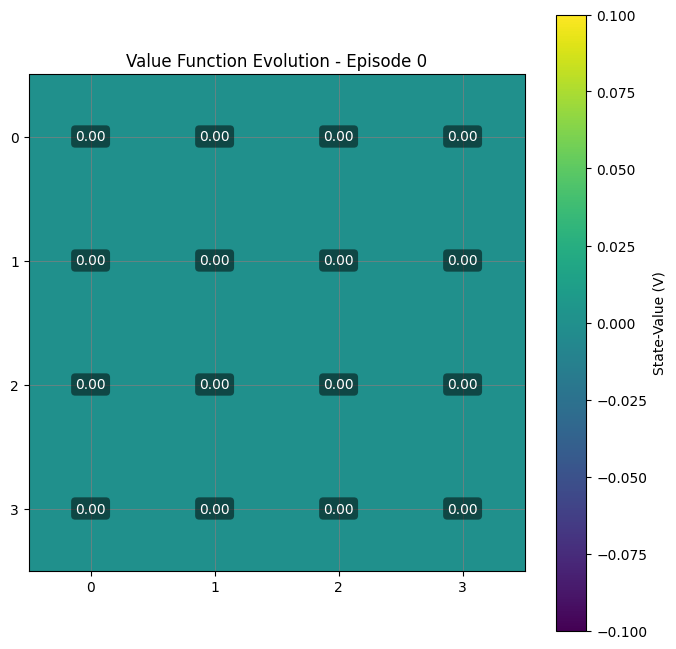


--- Animating Initial Policy (Episode 0) ---

Generating animation for policy (saving to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/policy_episode_0.gif)...

Animation captured 42 frames. Saving GIF...
Policy animation saved to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/policy_episode_0.gif


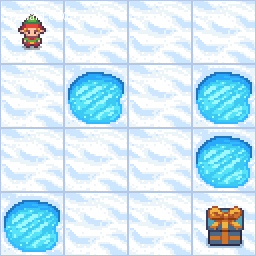


--- Starting Training ---


--- Bellman Backup Visualization ---
Episode: 100
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a): 0.0005
  Target Q: 0.0005
  TD Error: -0.0000
  Updated Q(s,a): 0.0005
----------------------------------

Episode 100/2000, Total Reward: 0.00, Epsilon: 0.6058

--- Bellman Backup Visualization ---
Episode: 200
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a): 0.0194
  Target Q: 0.0192
  TD Error: -0.0002
  Updated Q(s,a): 0.0194
----------------------------------

Episode 200/2000, Total Reward: 0.00, Epsilon: 0.3670

--- Bellman Backup Visualization ---
Episode: 300
State: 0, Action: 0, Reward: 0, Next State: 4, Done: False
  Current Q(s,a): 0.0728
  Target Q: 0.0791
  TD Error: 0.0063
  Updated Q(s,a): 0.0734
----------------------------------

Episode 300/2000, Total Reward: 0.00, Epsilon: 0.2223

--- Bellman Backup Visualization ---
Episode: 400
State: 0, Action: 0, Reward: 0, Next State: 4, Done: Fa

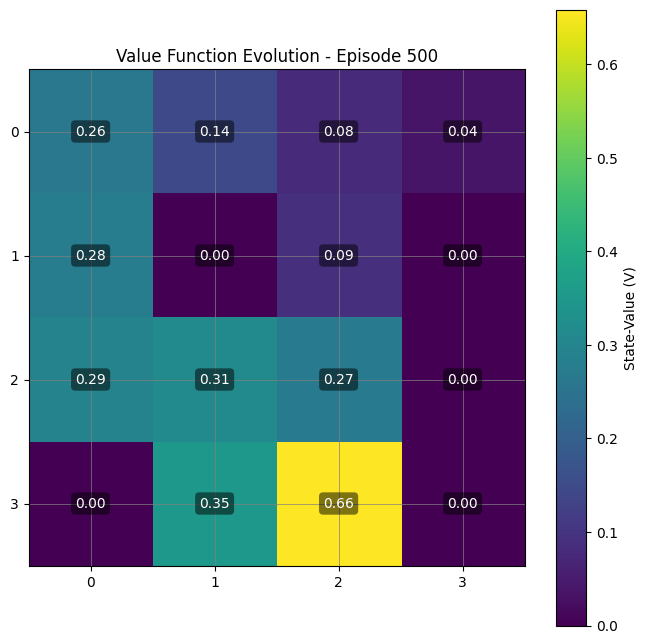


--- Bellman Backup Visualization ---
Episode: 600
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a): 0.3629
  Target Q: 0.3592
  TD Error: -0.0036
  Updated Q(s,a): 0.3625
----------------------------------

Episode 600/2000, Total Reward: 0.00, Epsilon: 0.0494

--- Bellman Backup Visualization ---
Episode: 700
State: 0, Action: 0, Reward: 0, Next State: 4, Done: False
  Current Q(s,a): 0.4856
  Target Q: 0.5054
  TD Error: 0.0197
  Updated Q(s,a): 0.4876
----------------------------------

Episode 700/2000, Total Reward: 1.00, Epsilon: 0.0299

--- Bellman Backup Visualization ---
Episode: 800
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a): 0.4648
  Target Q: 0.4601
  TD Error: -0.0046
  Updated Q(s,a): 0.4643
----------------------------------

Episode 800/2000, Total Reward: 1.00, Epsilon: 0.0181

--- Bellman Backup Visualization ---
Episode: 900
State: 0, Action: 0, Reward: 0, Next State: 4, Done: False
  Current Q(s,a): 0.4901

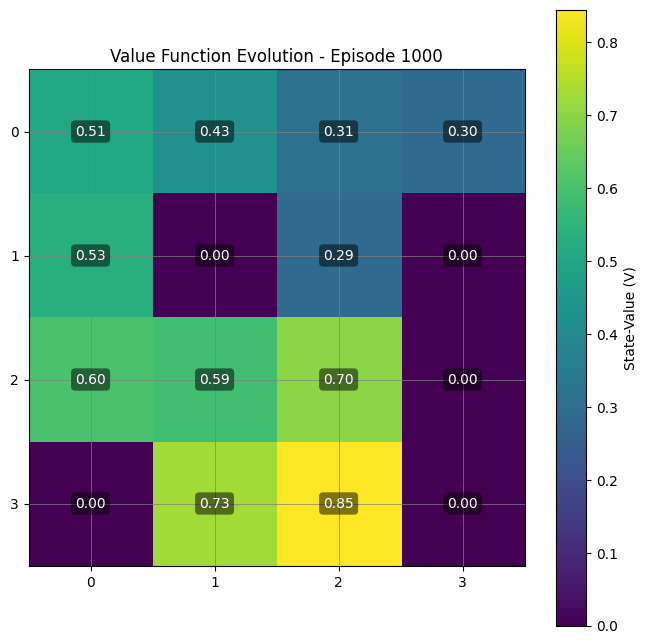


--- Animating Policy at Episode 1000 ---

Generating animation for policy (saving to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/policy_episode_1000.gif)...

Animation captured 20 frames. Saving GIF...
Policy animation saved to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/policy_episode_1000.gif


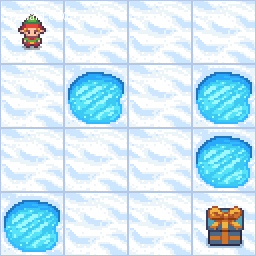


--- Bellman Backup Visualization ---
Episode: 1100
State: 0, Action: 0, Reward: 0, Next State: 4, Done: False
  Current Q(s,a): 0.4889
  Target Q: 0.5127
  TD Error: 0.0238
  Updated Q(s,a): 0.4913
----------------------------------

Episode 1100/2000, Total Reward: 0.00, Epsilon: 0.0100

--- Bellman Backup Visualization ---
Episode: 1200
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a): 0.5428
  Target Q: 0.5374
  TD Error: -0.0054
  Updated Q(s,a): 0.5423
----------------------------------

Episode 1200/2000, Total Reward: 1.00, Epsilon: 0.0100

--- Bellman Backup Visualization ---
Episode: 1300
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a): 0.5624
  Target Q: 0.5567
  TD Error: -0.0056
  Updated Q(s,a): 0.5618
----------------------------------

Episode 1300/2000, Total Reward: 1.00, Epsilon: 0.0100

--- Bellman Backup Visualization ---
Episode: 1400
State: 0, Action: 0, Reward: 0, Next State: 4, Done: False
  Current Q(s,a):

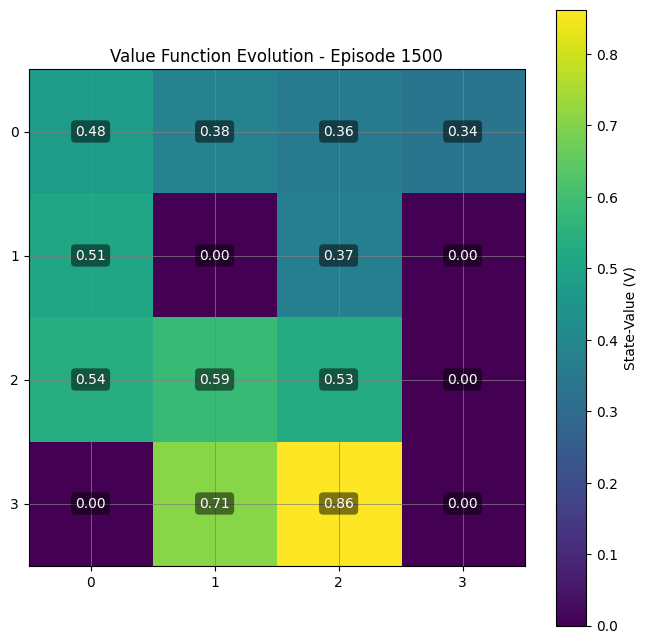


--- Bellman Backup Visualization ---
Episode: 1600
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a): 0.5268
  Target Q: 0.5215
  TD Error: -0.0053
  Updated Q(s,a): 0.5262
----------------------------------

Episode 1600/2000, Total Reward: 1.00, Epsilon: 0.0100

--- Bellman Backup Visualization ---
Episode: 1700
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a): 0.4932
  Target Q: 0.4883
  TD Error: -0.0049
  Updated Q(s,a): 0.4927
----------------------------------

Episode 1700/2000, Total Reward: 1.00, Epsilon: 0.0100

--- Bellman Backup Visualization ---
Episode: 1800
State: 0, Action: 0, Reward: 0, Next State: 4, Done: False
  Current Q(s,a): 0.4656
  Target Q: 0.4772
  TD Error: 0.0116
  Updated Q(s,a): 0.4668
----------------------------------

Episode 1800/2000, Total Reward: 1.00, Epsilon: 0.0100

--- Bellman Backup Visualization ---
Episode: 1900
State: 0, Action: 0, Reward: 0, Next State: 0, Done: False
  Current Q(s,a):

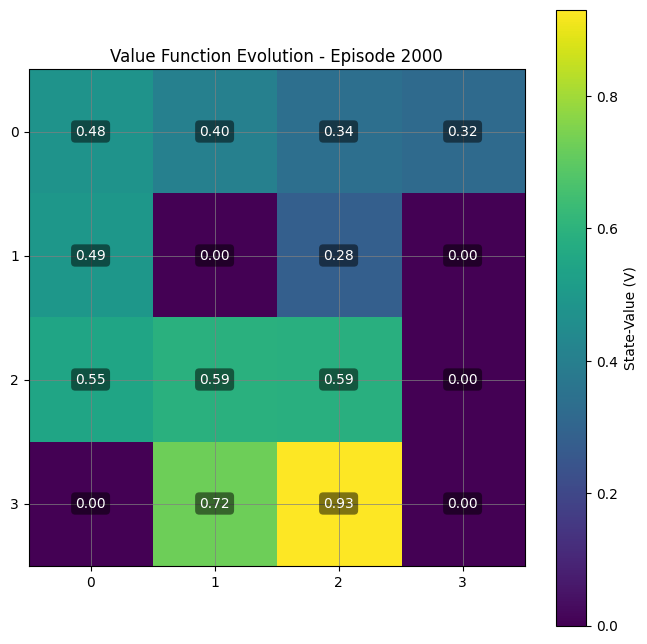


--- Animating Policy at Episode 2000 ---

Generating animation for policy (saving to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/policy_episode_2000.gif)...

Animation captured 21 frames. Saving GIF...
Policy animation saved to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/policy_episode_2000.gif


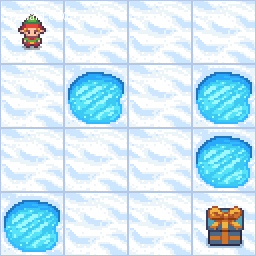


--- Training Finished ---



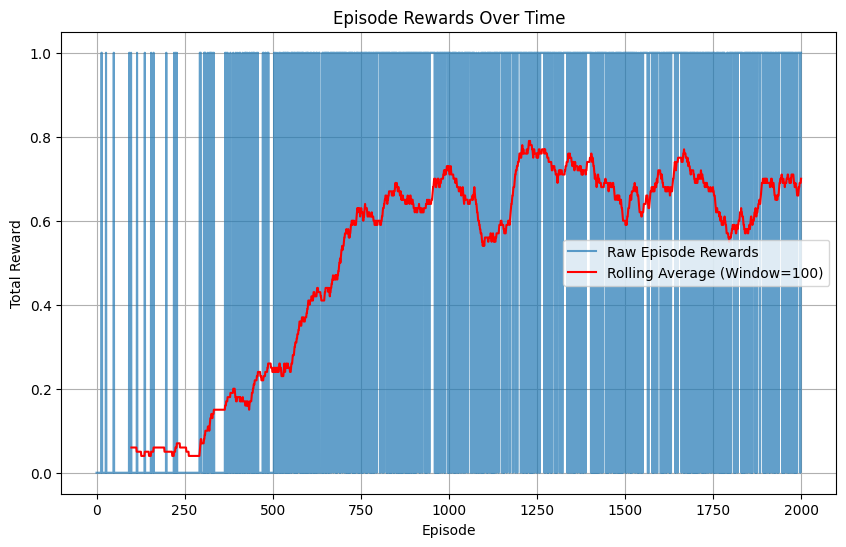

Learning curve saved to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/learning_curve.png
Final Q-table saved to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/final_q_table.csv
Final policy saved to ./output_FrozenLake-v1_QLearningAgent_20251120-014414/final_policy.csv
Key observations markdown file generated: ./output_FrozenLake-v1_QLearningAgent_20251120-014414/key_observations.md

--- Final Q-table ---



,Left,Down,Right,Up
State,,,,
0,0.477068,0.443210,0.462495,0.448705
1,0.068842,0.094557,0.052116,0.403574
2,0.140150,0.338924,0.072604,0.102373
3,0.068917,0.035377,0.040676,0.323122
4,0.491001,0.350568,0.383083,0.321370
5,0.000000,0.000000,0.000000,0.000000
6,0.281524,0.093482,0.053475,0.011337
7,0.000000,0.000000,0.000000,0.000000
8,0.288363,0.297129,0.449828,0.546960



--- Final Policy (argmax of Q-table) ---



,Optimal Action,Optimal Action Name
State,,
0,0,Left
1,3,Up
2,1,Down
3,3,Up
4,0,Left
5,0,Left
6,0,Left
7,0,Left
8,3,Up


In [ ]:
import pandas as pd

# Define Hyperparameters and Demonstration Intervals for Q-Learning
NUM_EPISODES = 2000          # Total number of episodes for training
MAX_STEPS_PER_EPISODE = 100  # Maximum steps per episode to prevent infinite loops
LEARNING_RATE = 0.1          # Alpha: How much new information overrides old information
DISCOUNT_FACTOR = 0.99       # Gamma: Importance of future rewards
INITIAL_EPSILON = 1.0        # Epsilon: Initial exploration rate
EPSILON_DECAY_RATE = 0.995   # Rate at which epsilon decays
MIN_EPSILON = 0.01           # Minimum exploration rate

VALUE_PLOT_INTERVAL = 500     # Plot value function every X episodes
BELLMAN_BACKUP_INTERVAL = 100 # Visualize Bellman backup at the start of every X episodes
POLICY_ANIMATION_INTERVAL = 1000 # Animate policy every X episodes

print("\n--- Demonstrating Q-Learning Agent ---")

# Instantiate RLDemonstrator with QLearningAgent
demonstrator_ql = RLDemonstrator(
    env_name='FrozenLake-v1',
    num_episodes=NUM_EPISODES,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
    gamma=DISCOUNT_FACTOR,
    initial_epsilon=INITIAL_EPSILON,
    epsilon_decay_rate=EPSILON_DECAY_RATE,
    min_epsilon=MIN_EPSILON,
    value_plot_interval=VALUE_PLOT_INTERVAL,
    bellman_backup_interval=BELLMAN_BACKUP_INTERVAL,
    policy_animation_interval=POLICY_ANIMATION_INTERVAL,
    agent_class=QLearningAgent,
    agent_kwargs={'alpha': LEARNING_RATE, 'gamma': DISCOUNT_FACTOR, 'epsilon': INITIAL_EPSILON}
)

# Run the training and demonstration
final_q_table, final_policy = demonstrator_ql.train()

# Display the final Q-table
print("\n--- Final Q-table ---\n")
# Create a DataFrame for better readability
q_table_df = pd.DataFrame(final_q_table, columns=['Left', 'Down', 'Right', 'Up'])
q_table_df.index.name = 'State'
display(q_table_df)

print("\n--- Final Policy (argmax of Q-table) ---\n")
# Display the final policy derived from the Q-table
policy_df = pd.DataFrame(final_policy, columns=['Optimal Action'])
policy_df.index.name = 'State'
policy_df['Optimal Action Name'] = policy_df['Optimal Action'].map({0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'})
display(policy_df)

## Q-learning Summary:

### Data Analysis Key Findings

*   **Q-learning Fundamentals**: Q-learning is a model-free, off-policy reinforcement learning algorithm that utilizes temporal difference (TD) learning to find optimal action-selection policies in finite Markov Decision Processes (MDPs).
*   **Q-Value Definition**: The "Q" in Q-learning refers to "Quality." A Q-value, `Q(s, a)`, quantifies the expected future reward for performing action `a` in state `s` and then following an optimal policy thereafter. The algorithm's goal is to construct a Q-table containing these values.
*   **Optimal Policy Derivation**: Once optimal Q-values (`Q*`) are learned, the optimal policy ($\pi^*$) for any state `s` is determined by selecting the action `a` that yields the maximum `Q*(s, a)`.
*   **Exploration-Exploitation Trade-off**: Q-learning balances exploration (discovering new actions) and exploitation (using known best actions) through strategies like epsilon-greedy. This strategy involves taking a random action with probability $\epsilon$ and the action with the highest Q-value with probability $1 - \epsilon$.
*   **Q-Value Update Rule (Bellman Equation)**: The algorithm iteratively updates Q-values using the formula: $Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$. This rule incorporates the learning rate ($\alpha$), immediate reward ($r$), discount factor ($\gamma$), and the maximum Q-value of the next state ($\max_{a'} Q(s', a')$), all contributing to the Temporal Difference (TD) Error.
*   **Key Characteristics**: Q-learning is characterized by being model-free (no need for environment dynamics), off-policy (learns optimal policy while following another), and offers guaranteed convergence to optimal Q-values under specific conditions (e.g., all state-action pairs visited infinitely often, appropriate learning rate decay).

### Insights or Next Steps

*   Q-learning's model-free nature makes it highly applicable to real-world problems where the environment's internal workings are unknown or too complex to model explicitly.
*   Effective implementation of Q-learning relies heavily on careful selection and decay of hyperparameters such as the learning rate ($\alpha$), discount factor ($\gamma$), and the epsilon ($\epsilon$) for the exploration-exploitation strategy.



--- Demonstrating Monte Carlo Agent ---
Output will be saved to: ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429

--- Initializing Environment ---
Initializing environment: FrozenLake-v1

Observation Space:
Discrete(16)

Action Space:
Discrete(4)

--- Initializing RL Agent ---
RLDemonstrator class initialized.

--- Visualizing Initial Value Function (Episode 0) ---

Value function plot saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/value_function_episode_0.png


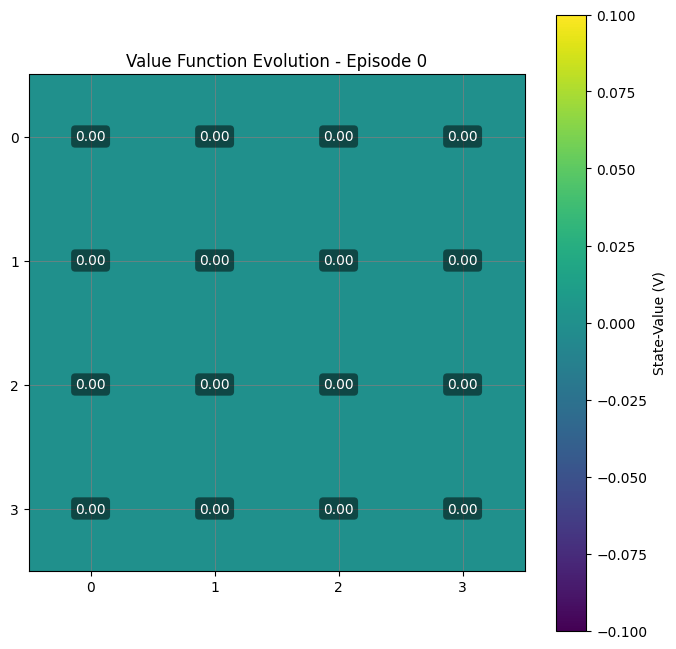


--- Animating Initial Policy (Episode 0) ---

Generating animation for policy (saving to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/policy_episode_0.gif)...

Animation captured 15 frames. Saving GIF...
Policy animation saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/policy_episode_0.gif


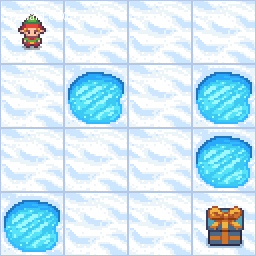


--- Starting Training ---

Episode 100/5000, Total Reward: 0.00, Epsilon: 0.9048
Episode 200/5000, Total Reward: 0.00, Epsilon: 0.8186
Episode 300/5000, Total Reward: 0.00, Epsilon: 0.7407
Episode 400/5000, Total Reward: 0.00, Epsilon: 0.6702
Episode 500/5000, Total Reward: 0.00, Epsilon: 0.6064
Episode 600/5000, Total Reward: 0.00, Epsilon: 0.5486
Episode 700/5000, Total Reward: 0.00, Epsilon: 0.4964
Episode 800/5000, Total Reward: 0.00, Epsilon: 0.4491
Episode 900/5000, Total Reward: 0.00, Epsilon: 0.4064
Episode 1000/5000, Total Reward: 0.00, Epsilon: 0.3677

--- Visualizing Value Function at Episode 1000 ---

Value function plot saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/value_function_episode_1000.png


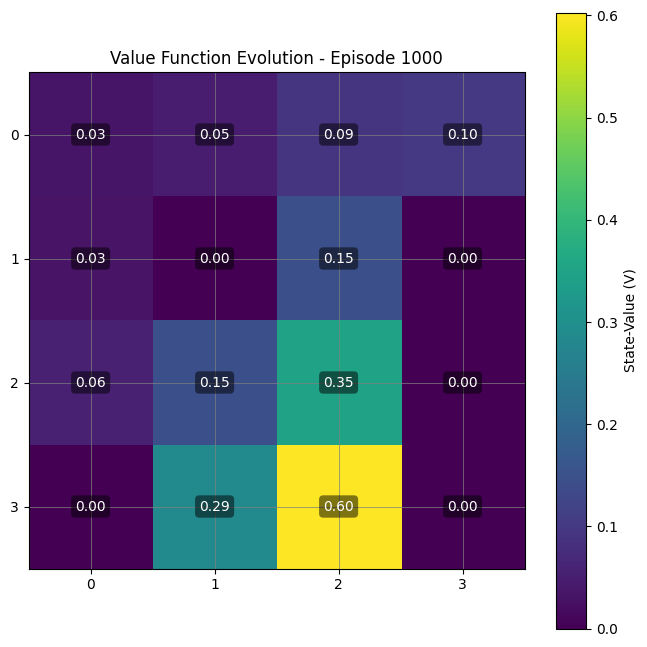

Episode 1100/5000, Total Reward: 0.00, Epsilon: 0.3327
Episode 1200/5000, Total Reward: 0.00, Epsilon: 0.3010
Episode 1300/5000, Total Reward: 1.00, Epsilon: 0.2724
Episode 1400/5000, Total Reward: 0.00, Epsilon: 0.2464
Episode 1500/5000, Total Reward: 1.00, Epsilon: 0.2230
Episode 1600/5000, Total Reward: 0.00, Epsilon: 0.2017
Episode 1700/5000, Total Reward: 0.00, Epsilon: 0.1825
Episode 1800/5000, Total Reward: 0.00, Epsilon: 0.1652
Episode 1900/5000, Total Reward: 0.00, Epsilon: 0.1494
Episode 2000/5000, Total Reward: 0.00, Epsilon: 0.1352

--- Visualizing Value Function at Episode 2000 ---

Value function plot saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/value_function_episode_2000.png


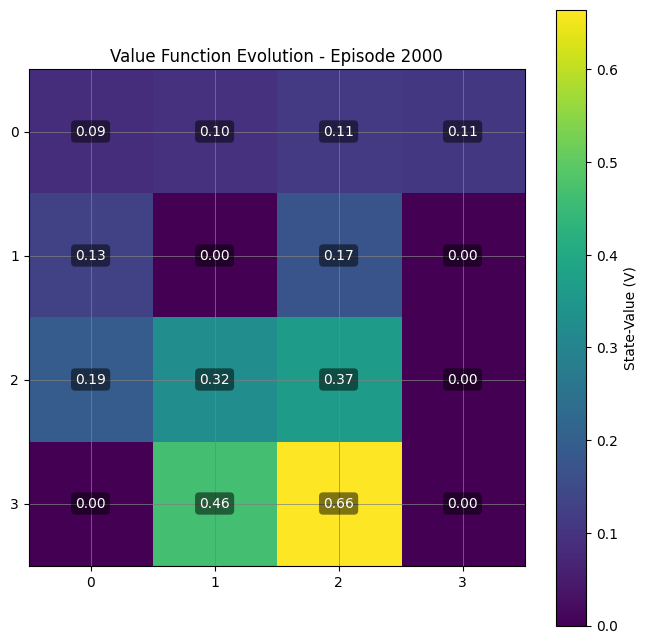

Episode 2100/5000, Total Reward: 0.00, Epsilon: 0.1223
Episode 2200/5000, Total Reward: 0.00, Epsilon: 0.1107
Episode 2300/5000, Total Reward: 0.00, Epsilon: 0.1001
Episode 2400/5000, Total Reward: 0.00, Epsilon: 0.0906
Episode 2500/5000, Total Reward: 0.00, Epsilon: 0.0820

--- Animating Policy at Episode 2500 ---

Generating animation for policy (saving to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/policy_episode_2500.gif)...

Animation captured 44 frames. Saving GIF...
Policy animation saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/policy_episode_2500.gif


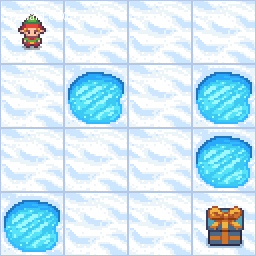

Episode 2600/5000, Total Reward: 0.00, Epsilon: 0.0742
Episode 2700/5000, Total Reward: 1.00, Epsilon: 0.0671
Episode 2800/5000, Total Reward: 0.00, Epsilon: 0.0607
Episode 2900/5000, Total Reward: 0.00, Epsilon: 0.0549
Episode 3000/5000, Total Reward: 1.00, Epsilon: 0.0500

--- Visualizing Value Function at Episode 3000 ---

Value function plot saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/value_function_episode_3000.png


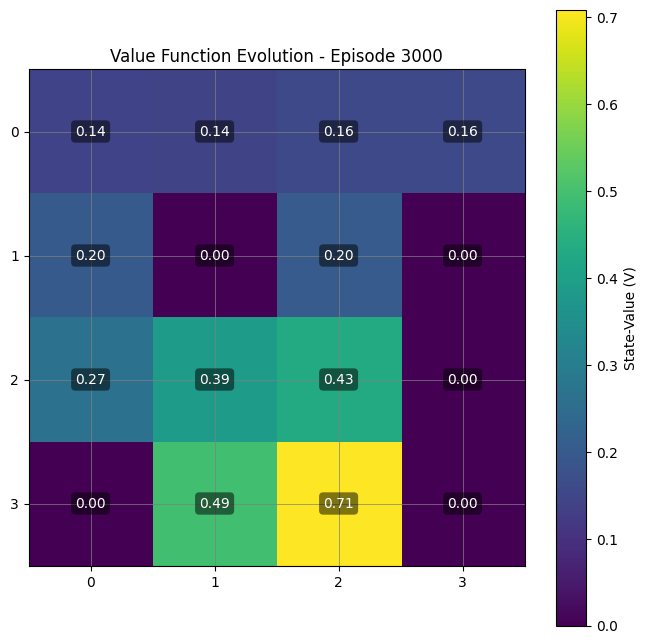

Episode 3100/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 3200/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 3300/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 3400/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 3500/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 3600/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 3700/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 3800/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 3900/5000, Total Reward: 1.00, Epsilon: 0.0500
Episode 4000/5000, Total Reward: 0.00, Epsilon: 0.0500

--- Visualizing Value Function at Episode 4000 ---

Value function plot saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/value_function_episode_4000.png


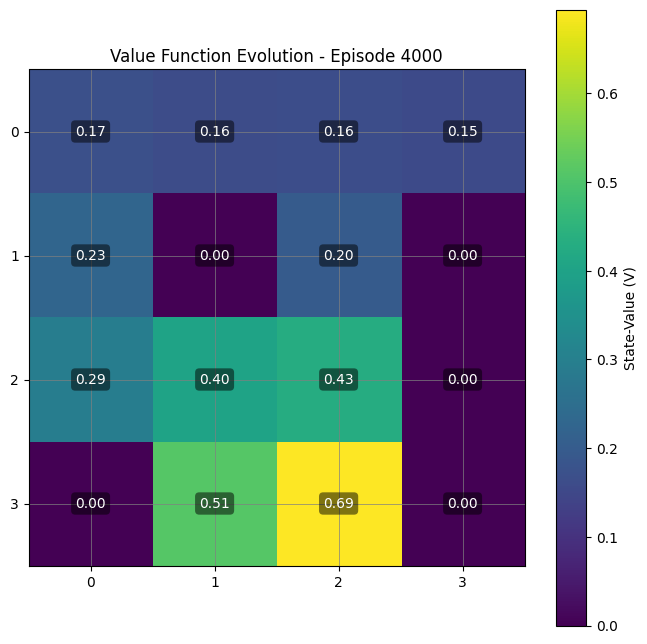

Episode 4100/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 4200/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 4300/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 4400/5000, Total Reward: 1.00, Epsilon: 0.0500
Episode 4500/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 4600/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 4700/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 4800/5000, Total Reward: 0.00, Epsilon: 0.0500
Episode 4900/5000, Total Reward: 1.00, Epsilon: 0.0500
Episode 5000/5000, Total Reward: 0.00, Epsilon: 0.0500

--- Visualizing Value Function at Episode 5000 ---

Value function plot saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/value_function_episode_5000.png


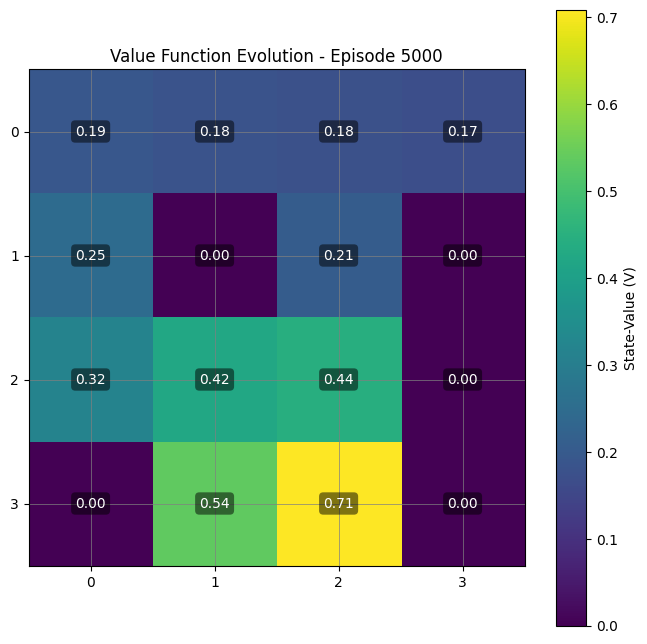


--- Animating Policy at Episode 5000 ---

Generating animation for policy (saving to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/policy_episode_5000.gif)...

Animation captured 8 frames. Saving GIF...
Policy animation saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/policy_episode_5000.gif


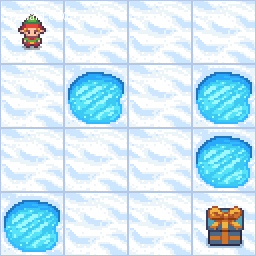


--- Training Finished ---



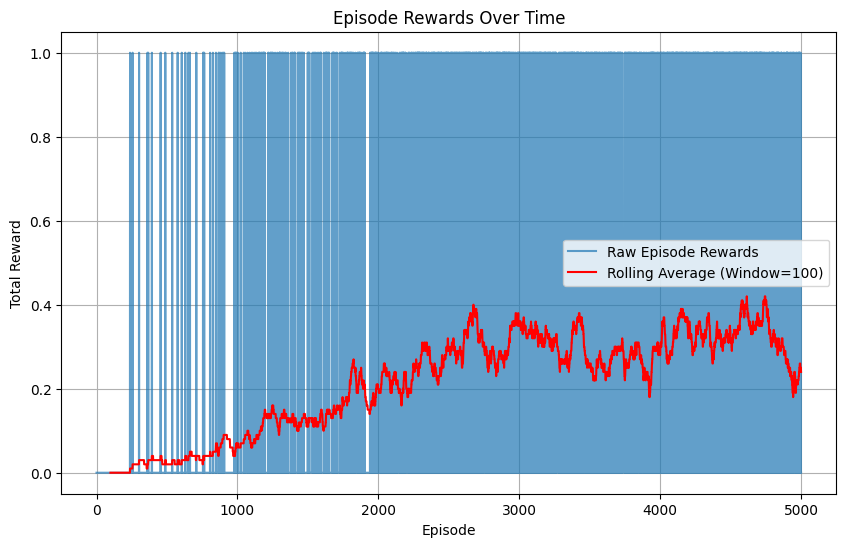

Learning curve saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/learning_curve.png
Final Q-table saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/final_q_table.csv
Final policy saved to ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/final_policy.csv
Key observations markdown file generated: ./output_FrozenLake-v1_MonteCarloAgent_20251120-014429/key_observations.md

--- Monte Carlo Final Q-table ---



,Left,Down,Right,Up
State,,,,
0,0.081833,0.193127,0.110797,0.086553
1,0.063783,0.062075,0.068061,0.181635
2,0.159504,0.106361,0.176141,0.125024
3,0.096383,0.093612,0.075769,0.170160
4,0.248674,0.100337,0.092368,0.070856
5,0.000000,0.000000,0.000000,0.000000
6,0.148158,0.101102,0.206358,0.019522
7,0.000000,0.000000,0.000000,0.000000
8,0.136538,0.167428,0.129992,0.317300



--- Monte Carlo Final Policy (argmax of Q-table) ---



,Optimal Action,Optimal Action Name
State,,
0,1,Down
1,3,Up
2,2,Right
3,3,Up
4,0,Left
5,0,Left
6,2,Right
7,0,Left
8,3,Up


In [ ]:
import pandas as pd

# Define Hyperparameters and Demonstration Intervals for Monte Carlo
NUM_EPISODES_MC = 5000          # Total number of episodes for training
MAX_STEPS_PER_EPISODE_MC = 100  # Maximum steps per episode to prevent infinite loops
DISCOUNT_FACTOR_MC = 0.99       # Gamma: Importance of future rewards
INITIAL_EPSILON_MC = 1.0        # Epsilon: Initial exploration rate
EPSILON_DECAY_RATE_MC = 0.999   # Rate at which epsilon decays (slower decay for MC)
MIN_EPSILON_MC = 0.05           # Minimum exploration rate

VALUE_PLOT_INTERVAL_MC = 1000     # Plot value function every X episodes
# Bellman backup is not directly applicable for episodic MC, so set to a high value or skip
BELLMAN_BACKUP_INTERVAL_MC = 1000000
POLICY_ANIMATION_INTERVAL_MC = 2500 # Animate policy every X episodes

print("\n--- Demonstrating Monte Carlo Agent ---")

# Instantiate RLDemonstrator with MonteCarloAgent
demonstrator_mc = RLDemonstrator(
    env_name='FrozenLake-v1',
    num_episodes=NUM_EPISODES_MC,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE_MC,
    gamma=DISCOUNT_FACTOR_MC,
    initial_epsilon=INITIAL_EPSILON_MC,
    epsilon_decay_rate=EPSILON_DECAY_RATE_MC,
    min_epsilon=MIN_EPSILON_MC,
    value_plot_interval=VALUE_PLOT_INTERVAL_MC,
    bellman_backup_interval=BELLMAN_BACKUP_INTERVAL_MC, # Bellman backup for MC is not relevant at each step
    policy_animation_interval=POLICY_ANIMATION_INTERVAL_MC,
    agent_class=MonteCarloAgent,
    agent_kwargs={'gamma': DISCOUNT_FACTOR_MC, 'epsilon': INITIAL_EPSILON_MC} # Epsilon will be updated by demonstrator
)

# Run the training and demonstration
final_q_table_mc, final_policy_mc = demonstrator_mc.train()

# Display the final Q-table for Monte Carlo
print("\n--- Monte Carlo Final Q-table ---\n")
# Create a DataFrame for better readability
q_table_df_mc = pd.DataFrame(final_q_table_mc, columns=['Left', 'Down', 'Right', 'Up'])
q_table_df_mc.index.name = 'State'
display(q_table_df_mc)

print("\n--- Monte Carlo Final Policy (argmax of Q-table) ---\n")
# Display the final policy derived from the Q-table
policy_df_mc = pd.DataFrame(final_policy_mc, columns=['Optimal Action'])
policy_df_mc.index.name = 'State'
policy_df_mc['Optimal Action Name'] = policy_df_mc['Optimal Action'].map({0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'})
display(policy_df_mc)

# Review Training Results and Provide Improvement Suggestions



## Analysis of Current Training Results:

Upon reviewing the 'Episode Rewards Over Time' plots and the console outputs for both the Q-Learning and Monte Carlo agents on the `FrozenLake-v1` environment, it's evident that neither agent consistently achieves the maximum possible reward of 1.0. Both agents exhibit periods of successful episodes (reward 1.0) but also frequently encounter episodes where the total reward is 0.0, even in later stages of training. This indicates suboptimal performance, as an ideal agent would consistently reach the goal.



## Common Reasons for Suboptimal Performance in RL:

1.  **Exploration-Exploitation Balance:** In stochastic environments like `FrozenLake-v1` (with its 'slippery' nature), balancing exploration (trying new actions) and exploitation (using known best actions) is crucial. If the agent exploits too early, it might converge to a suboptimal policy. If it explores too much, it might not consolidate learned knowledge efficiently.
2.  **Hyperparameter Tuning:** The learning rate (`alpha`), discount factor (`gamma`), initial epsilon, epsilon decay rate, and minimum epsilon are critical. Incorrect settings can lead to slow convergence, oscillation, or premature convergence to local optima.
3.  **Environment Stochasticity:** The inherent randomness of the `FrozenLake-v1` environment (slippery ice) makes learning harder. An action intended to move right might result in a move down, requiring a more robust policy than in a deterministic environment.
4.  **Insufficient Training:** While both agents ran for thousands of episodes, the complexity introduced by stochasticity might require even more interactions to fully converge to a truly optimal policy.
5.  **Episode Length:** A `max_steps_per_episode` that is too short might prevent the agent from reaching the goal even if it's following a good path, leading to many 0.0 reward episodes.



## Strategies for Improvement:

To improve the agents' learning and increase their chances of consistently achieving the optimal reward, consider the following strategies:

1.  **Epsilon Decay Rate & Minimum Epsilon Tuning:**
    *   **Slower Epsilon Decay:** A slower `epsilon_decay_rate` (e.g., closer to 1.0, like 0.9995 instead of 0.995 for Q-Learning) could allow the agent to explore more thoroughly before settling into a policy. This is especially useful in stochastic environments where initial random successes might be misleading.
    *   **Higher Minimum Epsilon:** Increasing `min_epsilon` (e.g., from 0.01 to 0.05 or 0.1) ensures continued exploration throughout training, which can help in stochastic environments where the optimal path might not be perfectly stable due to randomness.

2.  **Learning Rate (`alpha`) Tuning (for Q-Learning):**
    *   Experiment with different `alpha` values (e.g., 0.05, 0.2). A smaller `alpha` might lead to more stable learning but slower convergence, while a larger `alpha` can be faster but riskier, potentially causing the Q-values to oscillate.

3.  **Increase Number of Episodes:**
    *   For `FrozenLake-v1`, especially with high stochasticity, more episodes might be necessary for the Q-table to fully converge. Consider increasing `NUM_EPISODES` (e.g., to 5000-10000 for Q-Learning, and even more for Monte Carlo, like 10000-20000).

4.  **Adjust Discount Factor (`gamma`):**
    *   While 0.99 is generally a good starting point, slightly adjusting `gamma` (e.g., to 0.95 or 0.9) might change the agent's preference for immediate versus future rewards, which could be beneficial depending on the environment's reward structure and length of optimal paths.

5.  **Extend `max_steps_per_episode`:**
    *   If the agent is frequently running out of steps before reaching the goal, increasing `MAX_STEPS_PER_EPISODE` will give it more opportunities to complete an episode and receive a reward.

6.  **Consider Different Exploration Strategies (Beyond Epsilon-Greedy):**
    *   While epsilon-greedy is effective, more advanced strategies like Thompson Sampling or Upper Confidence Bound (UCB) might offer more efficient exploration in certain scenarios.

By carefully tuning these parameters and potentially extending the training duration, the agents are likely to learn more robust policies that can navigate the stochasticity of the FrozenLake environment and achieve higher, more consistent rewards.

## Understanding Rapid Oscillations in Episode Rewards

When observing the 'Episode Rewards Over Time' graph, especially in stochastic environments like `FrozenLake-v1`, you might notice that the raw episode rewards (often represented by a blue line) can appear as a 'solid band' or show very rapid, high-frequency fluctuations, particularly towards the later stages of training.

**Why Rapid Oscillation Occurs:**

1.  **Stochastic Environment:** The `FrozenLake-v1` environment is 'slippery'. This means that even if the agent chooses the optimal action, there's a chance it might slip to an unintended adjacent state. This inherent randomness introduces variance in episode outcomes.
2.  **Binary Rewards:** In `FrozenLake-v1`, the reward is typically 1.0 for reaching the goal and 0.0 for falling into a hole or running out of steps. This binary nature means that an agent either succeeds or fails. A single 'slip' can drastically change an episode's reward from 1.0 to 0.0.
3.  **Near-Optimal but Not Perfect Policy:** Towards the end of training, the agent has likely learned a good, but not perfectly robust, policy. It might successfully navigate to the goal for several episodes, but then a single unfortunate slip due to the environment's stochasticity can lead to a 0.0 reward. This constant switching between success (1.0) and failure (0.0) creates the rapid oscillation.
4.  **Visual Density:** When many episodes are plotted on a single graph, the individual data points become extremely dense. These rapid jumps between 0.0 and 1.0 (or other values) blend together visually, forming the 'solid blue' band you observe.

**What Can Be Done (and What the Rolling Average Shows):**

*   **Rolling Average:** The red line on the graph, representing the rolling average of rewards, is crucial for understanding the true learning trend. It smooths out these rapid fluctuations, providing a clearer picture of whether the agent's performance is improving, plateauing, or degrading over time. A high and stable rolling average indicates that the agent is *mostly* succeeding, even if individual episodes vary.
*   **Hyperparameter Tuning:** Refining parameters like `epsilon` decay rate and `min_epsilon` (to allow more exploration), `learning_rate` (`alpha`), and `discount_factor` (`gamma`) can help the agent learn a more robust policy. A higher `min_epsilon` might ensure continued exploration of paths that are more resilient to stochasticity.
*   **More Training Episodes:** In highly stochastic environments, more training episodes might be necessary for the Q-table to fully converge to a policy that can handle the random elements more effectively.
*   **Max Steps Per Episode:** Ensuring `max_steps_per_episode` is sufficient allows the agent enough time to reach the goal without being prematurely terminated.

For a detailed discussion on strategies to improve the agents' learning and achieve more consistent rewards, please refer to the section on **'Review Training Results and Provide Improvement Suggestions'**.

# Task: Save animations to Google Drive
Mount your Google Drive to `/content/drive/` to facilitate the transfer of the latest Q-Learning and Monte Carlo visualization directories to `RL_Project/rl_animations`, ensuring existing content in the target directory is archived beforehand.

## Mount Google Drive

### Subtask:
Mount your Google Drive to access the `RL_Project/rl_animations` directory.


**Reasoning**:
The subtask requires mounting Google Drive to access a specific directory. The provided instructions involve running Python code to achieve this.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Reasoning**:
The Google Drive is already mounted. The next step is to prepare the target directory by creating it if it doesn't exist, archiving any existing content, and then moving the newly generated Q-Learning and Monte Carlo output directories into the target Google Drive directory as specified by the task.



In [ ]:
import os
import shutil
import datetime
import re # Import regular expression module

# Define source directories by finding the latest generated ones
# This makes the script more robust against kernel restarts.
def get_latest_output_dir(agent_name):
    base_pattern = f"output_FrozenLake-v1_{agent_name}_"
    all_dirs = [d for d in os.listdir('.') if os.path.isdir(d) and d.startswith(base_pattern)]
    if not all_dirs:
        return None
    # Sort by creation/modification time, or by name (timestamp is in name)
    all_dirs.sort(reverse=True)
    return all_dirs[0]

ql_output_dir = get_latest_output_dir('QLearningAgent')
mc_output_dir = get_latest_output_dir('MonteCarloAgent')

# Define target base directory in Google Drive
target_base_dir = '/content/drive/MyDrive/RL_Project/rl_animations'

# Create target base directory if it doesn't exist
os.makedirs(target_base_dir, exist_ok=True)
print(f"Ensured target directory exists: {target_base_dir}")

# Archive existing content in target_base_dir
current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
archive_dir = os.path.join(target_base_dir, f"archive_{current_timestamp}")

# Check if there are any files or subdirectories to archive
items_to_archive = [f for f in os.listdir(target_base_dir) if f not in ['archive', 'archive_dir'] and not f.startswith('archive_')]

if items_to_archive:
    os.makedirs(archive_dir, exist_ok=True)
    print(f"Archiving existing content to: {archive_dir}")
    for item in items_to_archive:
        src_path = os.path.join(target_base_dir, item)
        dst_path = os.path.join(archive_dir, item)
        if os.path.isdir(src_path):
            shutil.move(src_path, dst_path)
        else:
            shutil.move(src_path, dst_path)
else:
    print("No existing content to archive in the target directory.")

# Copy the new output directories to the target Google Drive directory
if ql_output_dir and os.path.exists(ql_output_dir):
    destination_path = os.path.join(target_base_dir, os.path.basename(ql_output_dir))
    if os.path.exists(destination_path):
        print(f"Skipping Q-Learning copy: {destination_path} already exists. Consider deleting or archiving manually if needed.")
    else:
        shutil.copytree(ql_output_dir, destination_path)
        print(f"Copied Q-Learning results from {ql_output_dir} to {target_base_dir}")
else:
    print(f"Warning: Q-Learning output directory not found locally with pattern 'output_FrozenLake-v1_QLearningAgent_' in current directory.")

if mc_output_dir and os.path.exists(mc_output_dir):
    destination_path = os.path.join(target_base_dir, os.path.basename(mc_output_dir))
    if os.path.exists(destination_path):
        print(f"Skipping Monte Carlo copy: {destination_path} already exists. Consider deleting or archiving manually if needed.")
    else:
        shutil.copytree(mc_output_dir, destination_path)
        print(f"Copied Monte Carlo results from {mc_output_dir} to {target_base_dir}")
else:
    print(f"Warning: Monte Carlo output directory not found locally with pattern 'output_FrozenLake-v1_MonteCarloAgent_' in current directory.")

print("Artifact transfer complete.")

Ensured target directory exists: /content/drive/MyDrive/RL_Project/rl_animations
Archiving existing content to: /content/drive/MyDrive/RL_Project/rl_animations/archive_20251202-183300
Artifact transfer complete.


In [ ]:
# The 'ql_output_dir' is copied to 'target_base_dir' to:
# 1. Persist results: Save all generated plots, animations, and data (Q-tables, policies, markdown summaries) to Google Drive, as local Colab files are temporary.
# 2. Organize project artifacts: Store all experiment outputs in a designated, centralized location within Google Drive for easy access and management.
# 3. Facilitate review and sharing: Allow access to the results outside the Colab environment and enable sharing.

## Verify Google Drive Content

### Subtask:
Verify that the new output directories and the archived content are correctly placed in the Google Drive target directory.


**Reasoning**:
To verify the contents of the Google Drive target directory, I need to list its contents using a shell command. The `ls -l` command will show the directories and their modification times, allowing confirmation of the transfer.



In [ ]:
import os

# Define target base directory in Google Drive
target_base_dir = '/content/drive/MyDrive/RL_Project/rl_animations'

print(f"Listing contents of {target_base_dir}:")
!ls -l "{target_base_dir}"

Listing contents of /content/drive/MyDrive/RL_Project/rl_animations:
total 28
drwx------ 2 root root 4096 Nov 16 19:06 archive_20251116-190625
drwx------ 2 root root 4096 Nov 16 19:11 archive_20251116-191102
drwx------ 4 root root 4096 Nov 20 00:42 archive_20251120-004248
drwx------ 4 root root 4096 Nov 20 01:43 archive_20251120-014336
drwx------ 4 root root 4096 Nov 20 01:44 archive_20251120-014439
drwx------ 2 root root 4096 Nov 20 01:44 output_FrozenLake-v1_MonteCarloAgent_20251120-014429
drwx------ 2 root root 4096 Nov 20 01:44 output_FrozenLake-v1_QLearningAgent_20251120-014414


In [ ]:
print("Done")

Done
